# Importing Libraries

In [1]:
import os, glob, cv2, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import kagglehub

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Global Variables

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256
BATCH_SIZE = 26
EPOCHS = 30
LR = 3e-4

# Downloading Dataset

In [3]:
isic2018_path = kagglehub.dataset_download(
    "tschandl/isic2018-challenge-task1-data-segmentation"
)

In [4]:
all_2018_imgs = glob.glob(isic2018_path + "/**/*.jpg", recursive=True)
all_2018_masks = glob.glob(isic2018_path + "/**/*.png", recursive=True)

img_paths = sorted([p for p in all_2018_imgs if "Training_Input" in p])
mask_paths = sorted([p for p in all_2018_masks if "Training_GroundTruth" in p])

print(len(img_paths), len(mask_paths))
print(img_paths[:2])
print(mask_paths[:2])

2594 2594
['/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1-2_Training_Input/ISIC_0000000.jpg', '/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1-2_Training_Input/ISIC_0000001.jpg']
['/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1_Training_GroundTruth/ISIC_0000000_segmentation.png', '/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1_Training_GroundTruth/ISIC_0000001_segmentation.png']


# Basice Augmentations

In [5]:
train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

# Dataset Class

In [6]:
class ISICSegDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))

        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"].unsqueeze(0).float()

        return image, mask

# Dataset Splitting
- Train
- Validation

In [7]:
dataset = ISICSegDataset(img_paths, mask_paths, transform=train_tfms)

val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_ds.dataset.transform = train_tfms
val_ds.dataset.transform = val_tfms

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Declaring UNet Model

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet5Layer(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.enc5 = DoubleConv(512, 1024)

        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        e5 = self.enc5(self.pool(e4))

        d4 = self.up4(e5)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

# Loss Function

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        dice = (2 * intersection + self.smooth) / (
            probs.sum(dim=1) + targets.sum(dim=1) + self.smooth
        )

        return 1 - dice.mean()


def dice_score(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    dice = (2 * intersection + 1e-6) / (
        preds.sum(dim=1) + targets.sum(dim=1) + 1e-6
    )

    return dice.mean().item()

# Drive Mount

In [10]:
from google.colab import drive
drive.mount('/content/drive')


save_path = "/content/drive/MyDrive/isic2018_unet5_best.pth"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Traning Loop

In [11]:
model = UNet5Layer().to(DEVICE)

bce = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

best_dice = 0.0
patience = 7
early_stop_counter = 0
min_delta = 1e-4


for epoch in range(EPOCHS):
    print("\n" + "=" * 80)
    print(f"Epoch [{epoch + 1}/{EPOCHS}]")
    print("=" * 80)

    # =========================
    # Train
    # =========================
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader, desc="Training"):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)

        loss = bce(logits, masks) + dice_loss(logits, masks)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # =========================
    # Validation
    # =========================
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation"):
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            logits = model(images)

            loss = bce(logits, masks) + dice_loss(logits, masks)

            val_loss += loss.item()
            val_dice += dice_score(logits, masks)

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )

    # =========================
    # Save Best + Early Stopping
    # =========================
    if val_dice > best_dice + min_delta:
        best_dice = val_dice
        early_stop_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_dice": best_dice,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_dice": val_dice,
        }, save_path)

        print(f"Saved best model | Best Dice: {best_dice:.4f}")

    else:
        early_stop_counter += 1

        print(
            f"No Dice improvement | "
            f"Early Stop Counter: {early_stop_counter}/{patience}"
        )

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

print(f"Training finished. Best Val Dice: {best_dice:.4f}")


Epoch [1/30]


Validation: 100%|██████████| 20/20 [01:37<00:00,  4.87s/it]


Train Loss: 0.8967 | Val Loss: 0.8901 | Val Dice: 0.6810
Saved best model | Best Dice: 0.6810

Epoch [2/30]


Validation: 100%|██████████| 20/20 [01:32<00:00,  4.62s/it]


Train Loss: 0.6940 | Val Loss: 0.5911 | Val Dice: 0.7794
Saved best model | Best Dice: 0.7794

Epoch [3/30]


...

Train Loss: 0.4560 | Val Loss: 0.4062 | Val Dice: 0.8155
No Dice improvement | Early Stop Counter: 1/7

Epoch [7/30]


Validation: 100%|██████████| 20/20 [01:31<00:00,  4.55s/it]


Train Loss: 0.4330 | Val Loss: 0.4776 | Val Dice: 0.7845
No Dice improvement | Early Stop Counter: 2/7

Epoch [8/30]


Training:  70%|███████   | 56/80 [04:23<01:52,  4.70s/it]


KeyboardInterrupt: 

# Visualization of Segmnetations with Overlay

In [12]:
import matplotlib.pyplot as plt
import random
import numpy as np
import torch

def visualize_segmentation(model, val_dataset, device, n=5, threshold=0.5):
    model.eval()

    indices = random.sample(range(len(val_dataset)), n)

    plt.figure(figsize=(12, 4 * n))

    with torch.no_grad():
        for row, idx in enumerate(indices):
            image, true_mask = val_dataset[idx]

            x = image.unsqueeze(0).to(device)

            logits = model(x)
            prob_mask = torch.sigmoid(logits)[0, 0].cpu().numpy()
            pred_mask = (prob_mask > threshold).astype(np.uint8)

            img = image.permute(1, 2, 0).cpu().numpy()

            # Undo ImageNet normalization
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)

            # 1st column: real image
            plt.subplot(n, 3, row * 3 + 1)
            plt.imshow(img)
            plt.title("Real Image")
            plt.axis("off")

            # 2nd column: prediction
            plt.subplot(n, 3, row * 3 + 2)
            plt.imshow(pred_mask, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

            # 3rd column: overlay
            plt.subplot(n, 3, row * 3 + 3)
            plt.imshow(img)
            plt.imshow(pred_mask, cmap="jet", alpha=0.35)
            plt.title("Overlay")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

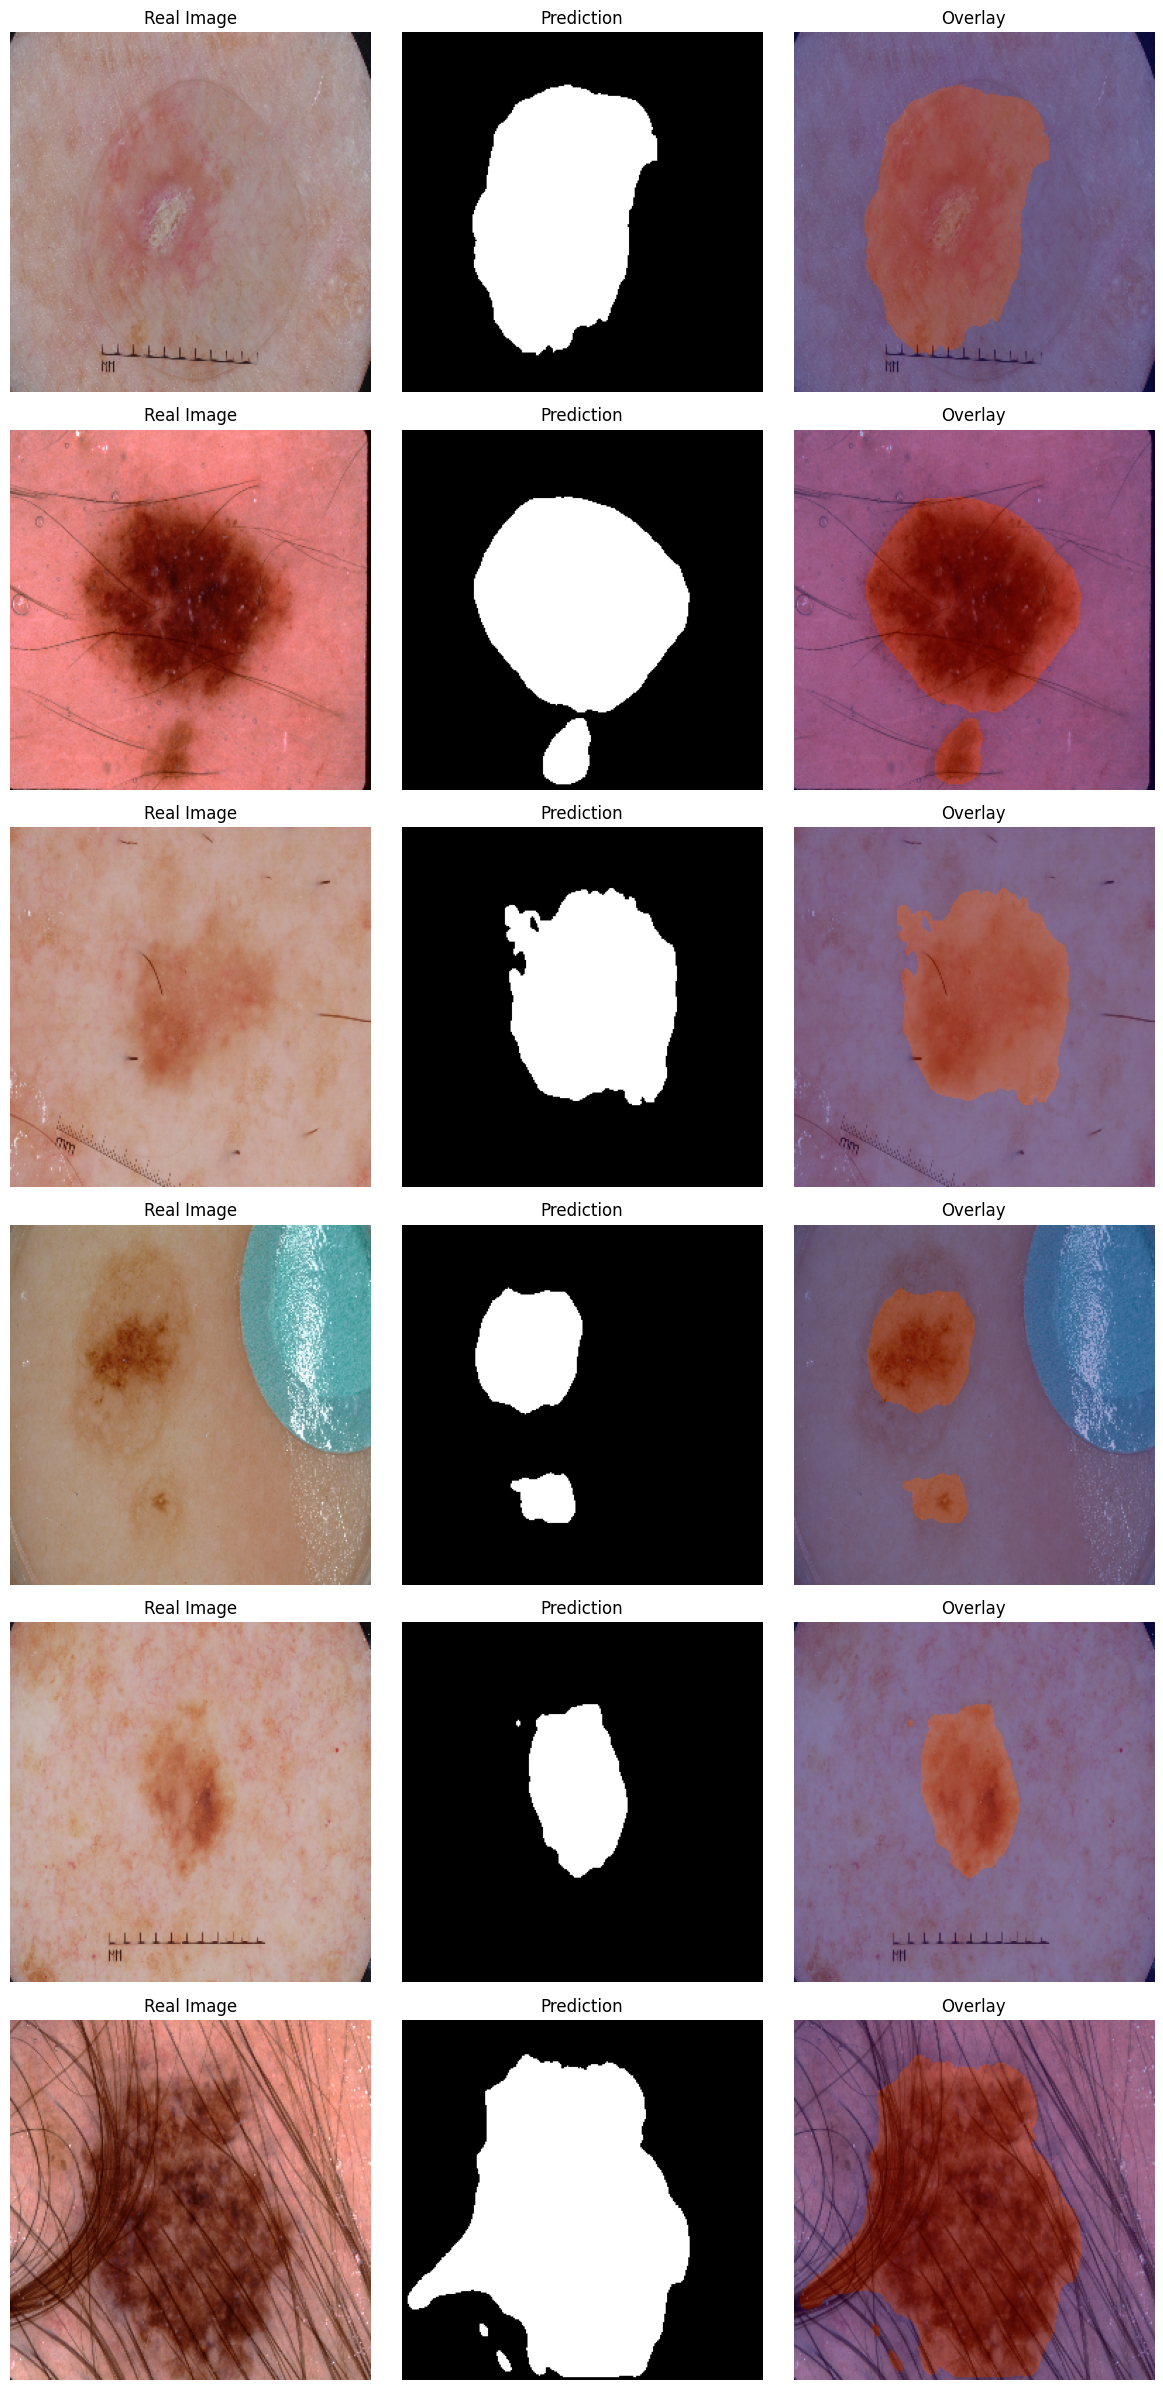

In [13]:
visualize_segmentation(
    model=model,
    val_dataset=val_ds,
    device=DEVICE,
    n=6,
    threshold=0.5
)